# 02 — Exploration des données formattées (Yahoo Finance)

Lecture du fichier `formatted/yahoofinance/wti.parquet` depuis S3 (LocalStack) pour vérifier le résultat du script `clean_yfinance.py`.

In [1]:
import io
import os
import boto3
import pandas as pd

# ── Connexion S3 LocalStack ──
os.environ["AWS_ACCESS_KEY_ID"] = "test"
os.environ["AWS_SECRET_ACCESS_KEY"] = "test"
os.environ["AWS_DEFAULT_REGION"] = "eu-west-1"

s3 = boto3.client("s3", endpoint_url="http://localhost:4566")

# ── Lecture du parquet formatté (dossier Spark) ──
# Spark écrit un dossier wti.parquet/ contenant _SUCCESS + part-*.parquet
prefix = "formatted/yahoofinance/wti.parquet/"
objs = s3.list_objects_v2(Bucket="datalake", Prefix=prefix)
parquet_key = [o["Key"] for o in objs.get("Contents", []) if o["Key"].endswith(".parquet")][0]

response = s3.get_object(Bucket="datalake", Key=parquet_key)
df = pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow")

print(f"Shape : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nPlage : {df['Datetime'].min()} → {df['Datetime'].max()}")
df.head()

Shape : 3440 lignes × 8 colonnes

Types :
Datetime            datetime64[ns]
Close                      float64
High                       float64
Low                        float64
Open                       float64
Volume                       int64
Volatility_Range           float64
Variation_Pct              float64
dtype: object

Plage : 2026-01-04 23:00:00 → 2026-03-02 20:30:00


,Datetime,Close,High,Low,Open,Volume,Volatility_Range,Variation_Pct
0,2026-01-04 23:00:00,56.959999,57.020000,56.939999,56.950001,347,0.08,NaN
1,2026-01-04 23:15:00,57.119999,57.150002,56.959999,56.970001,1553,0.19,0.2809
2,2026-01-04 23:30:00,57.099998,57.139999,56.990002,57.110001,1018,0.15,-0.0350
3,2026-01-04 23:45:00,57.320000,57.380001,57.070000,57.099998,1562,0.31,0.3853
4,2026-01-05 00:00:00,57.369999,57.450001,57.310001,57.320000,1080,0.14,0.0872


In [2]:
# ── Vérification qualité ──
print("Valeurs manquantes :")
print(df.isnull().sum())
print(f"\nDoublons sur Datetime : {df.duplicated(subset=['Datetime']).sum()}")
print(f"\nStatistiques :")
df.describe().round(2)

Valeurs manquantes :
Datetime            0
Close               0
High                0
Low                 0
Open                0
Volume              0
Volatility_Range    0
Variation_Pct       1
dtype: int64

Doublons sur Datetime : 0

Statistiques :


,Datetime,Close,High,Low,Open,Volume,Volatility_Range,Variation_Pct
count,3440,3440.00,3440.00,3440.00,3440.00,3440.00,3440.00,3439.00
mean,2026-02-01 16:59:21.279069696,62.49,62.59,62.39,62.49,3737.02,0.20,0.01
min,2026-01-04 23:00:00,55.87,55.97,55.76,55.87,0.00,0.02,-5.83
25%,2026-01-16 10:11:15,59.84,59.91,59.76,59.83,692.50,0.11,-0.10
50%,2026-02-03 04:07:30,62.81,62.89,62.72,62.81,2016.00,0.16,0.00
75%,2026-02-17 12:33:45,64.89,64.99,64.78,64.89,5005.25,0.24,0.12
max,2026-03-02 20:30:00,73.24,73.37,72.82,73.23,118942.00,2.59,7.79
std,NaN,3.25,3.27,3.22,3.25,5224.71,0.16,0.29


In [3]:
# ── Aperçu dernières lignes ──
print("Dernières lignes :")
df.tail(50)

Dernières lignes :


,Datetime,Close,High,Low,Open,Volume,Volatility_Range,Variation_Pct
3390,2026-03-02 08:15:00,72.989998,73.370003,72.820000,72.889999,11395,0.55,0.1372
3391,2026-03-02 08:30:00,72.440002,73.250000,72.080002,72.989998,11508,1.17,-0.7535
3392,2026-03-02 08:45:00,72.550003,72.849998,72.370003,72.440002,7685,0.48,0.1519
3393,2026-03-02 09:00:00,72.080002,72.540001,71.800003,72.529999,10756,0.74,-0.6478
3394,2026-03-02 09:15:00,71.889999,72.339996,71.809998,72.089996,6235,0.53,-0.2636
3395,2026-03-02 09:30:00,72.139999,72.410004,71.750000,71.900002,7286,0.66,0.3478
3396,2026-03-02 09:45:00,72.419998,72.480003,71.919998,72.139999,4539,0.56,0.3881
3397,2026-03-02 10:00:00,72.029999,72.449997,71.279999,72.430000,13054,1.17,-0.5385
3398,2026-03-02 10:15:00,72.029999,72.290001,71.820000,72.029999,4690,0.47,0.0000
3399,2026-03-02 10:30:00,71.910004,72.120003,71.660004,72.019997,5704,0.46,-0.1666


---
# Exploration des données formattées (GDELT)

Lecture du fichier `formatted/gdelt/events.parquet` depuis S3 (LocalStack) pour vérifier le résultat du script `clean_gdelt.py`.

In [4]:
# ═══════════════════════════════════════════════
# Chargement du Parquet formatté GDELT depuis S3
# ═══════════════════════════════════════════════
prefix_gdelt = "formatted/gdelt/events.parquet/"
objs_gdelt = s3.list_objects_v2(Bucket="datalake", Prefix=prefix_gdelt)
parquet_keys_gdelt = [o["Key"] for o in objs_gdelt.get("Contents", []) if o["Key"].endswith(".parquet")]

# Spark peut écrire plusieurs partitions → on les concat
dfs = []
for key in parquet_keys_gdelt:
    response = s3.get_object(Bucket="datalake", Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow"))

df_gdelt = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print(f"Shape : {df_gdelt.shape[0]} lignes × {df_gdelt.shape[1]} colonnes")
print(f"\nTypes :\n{df_gdelt.dtypes}")
print(f"\nColonnes : {list(df_gdelt.columns)}")
df_gdelt.head()

Shape : 734283 lignes × 28 colonnes

Types :
GlobalEventID                     int64
Day                              object
DATEADDED                datetime64[ns]
Actor1Code                       object
Actor1Name                       object
Actor1CountryCode                object
Actor1Type1Code                  object
Actor2Code                       object
Actor2Name                       object
Actor2CountryCode                object
Actor2Type1Code                  object
EventCode                         int32
EventRootCode                     int32
QuadClass                         int32
GoldsteinScale                  float64
IsRootEvent                       int32
ActionGeo_CountryCode            object
ActionGeo_Lat                   float64
ActionGeo_Long                  float64
NumMentions                       int32
NumSources                        int32
NumArticles                       int32
AvgTone                         float64
geo_I                           flo

,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,geo_I,geo_B,geo_S,geo_score_raw,dominant_country
0,1282069477,2026-01-04,2026-01-03 23:00:00,None,None,None,None,AUS,AUSTRALIA,AUS,...,149.9830,4,1,4,1.608187,1.0,1.609438,2.500000,4.023595,None
1,1282069529,2026-01-04,2026-01-03 23:00:00,None,None,None,None,IRL,LIMERICK,IRL,...,NaN,10,1,10,-7.547170,1.0,2.397895,1.825472,4.377290,None
2,1282069542,2026-01-04,2026-01-03 23:00:00,None,None,None,None,LEG,CONGRESS,None,...,-77.0364,20,2,20,-4.117647,1.0,3.044522,1.791176,5.453277,None
3,1282069544,2026-01-04,2026-01-03 23:00:00,None,None,None,None,LEG,CHAMBER,None,...,NaN,10,1,10,-1.865369,1.0,2.397895,2.443654,5.859626,None
4,1282069551,2026-01-04,2026-01-03 23:00:00,None,None,None,None,MIL,MILITARY,None,...,-66.9167,15,5,15,-4.152432,1.0,2.772589,2.541524,7.046602,None


In [5]:
print(df_gdelt.columns)

Index(['GlobalEventID', 'Day', 'DATEADDED', 'Actor1Code', 'Actor1Name',
       'Actor1CountryCode', 'Actor1Type1Code', 'Actor2Code', 'Actor2Name',
       'Actor2CountryCode', 'Actor2Type1Code', 'EventCode', 'EventRootCode',
       'QuadClass', 'GoldsteinScale', 'IsRootEvent', 'ActionGeo_CountryCode',
       'ActionGeo_Lat', 'ActionGeo_Long', 'NumMentions', 'NumSources',
       'NumArticles', 'AvgTone', 'geo_I', 'geo_B', 'geo_S', 'geo_score_raw',
       'dominant_country'],
      dtype='object')


In [6]:
# ═══════════════════════════════════════════════
# Statistiques descriptives GDELT
# ═══════════════════════════════════════════════
print("Valeurs manquantes :")
print(df_gdelt.isnull().sum())
print(f"\nDoublons sur GlobalEventID : {df_gdelt.duplicated(subset=['GlobalEventID']).sum()}")
print(f"\nPlage temporelle : {df_gdelt['DATEADDED'].min()} → {df_gdelt['DATEADDED'].max()}")
print(f"\nStatistiques numériques :")
df_gdelt.describe().round(2)

Valeurs manquantes :
GlobalEventID                 0
Day                           0
DATEADDED                     0
Actor1Code                77986
Actor1Name                77984
Actor1CountryCode        375210
Actor1Type1Code          381287
Actor2Code               248116
Actor2Name               248116
Actor2CountryCode        470735
Actor2Type1Code          474963
EventCode                     0
EventRootCode                 0
QuadClass                     0
GoldsteinScale                0
IsRootEvent                   0
ActionGeo_CountryCode     47201
ActionGeo_Lat             47517
ActionGeo_Long            47319
NumMentions                   0
NumSources                    0
NumArticles                   0
AvgTone                       0
geo_I                         0
geo_B                         0
geo_S                         0
geo_score_raw                 0
dominant_country         280433
dtype: int64

Doublons sur GlobalEventID : 0

Plage temporelle : 2026-01-03 23:00:0

,GlobalEventID,DATEADDED,EventCode,EventRootCode,QuadClass,GoldsteinScale,IsRootEvent,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,geo_I,geo_B,geo_S,geo_score_raw
count,7.342830e+05,734283,734283.00,734283.00,734283.00,734283.00,734283.00,686766.00,686964.00,734283.00,734283.00,734283.00,734283.00,734283.00,734283.00,734283.00,734283.00
mean,1.287024e+09,2026-02-02 00:44:32.027406592,239.95,14.19,3.32,-3.85,0.61,31.31,-10.77,7.34,1.09,7.11,-4.01,2.11,2.02,1.87,25.45
min,1.282069e+09,2026-01-03 23:00:00,60.00,6.00,2.00,-10.00,0.00,-85.62,-179.87,4.00,1.00,4.00,-34.62,1.00,1.61,1.00,1.61
25%,1.284506e+09,2026-01-18 04:45:00,100.00,8.00,2.00,-9.50,0.00,25.05,-83.28,5.00,1.00,4.00,-6.73,1.00,1.61,1.08,3.91
50%,1.287021e+09,2026-02-02 04:15:00,173.00,17.00,4.00,-5.00,1.00,35.75,-0.42,6.00,1.00,6.00,-3.99,1.00,1.95,1.84,6.14
75%,1.289518e+09,2026-02-17 01:30:00,190.00,19.00,4.00,5.00,1.00,42.65,48.17,10.00,1.00,10.00,-1.23,3.00,2.40,2.50,31.29
max,1.291970e+09,2026-03-02 19:45:00,1832.00,20.00,4.00,10.00,1.00,83.60,180.00,940.00,32.00,375.00,20.00,8.50,5.93,2.85,792.70
std,2.869307e+06,NaN,319.30,4.82,0.86,6.46,0.49,20.11,78.38,4.93,0.57,4.22,4.24,1.48,0.35,0.58,43.51


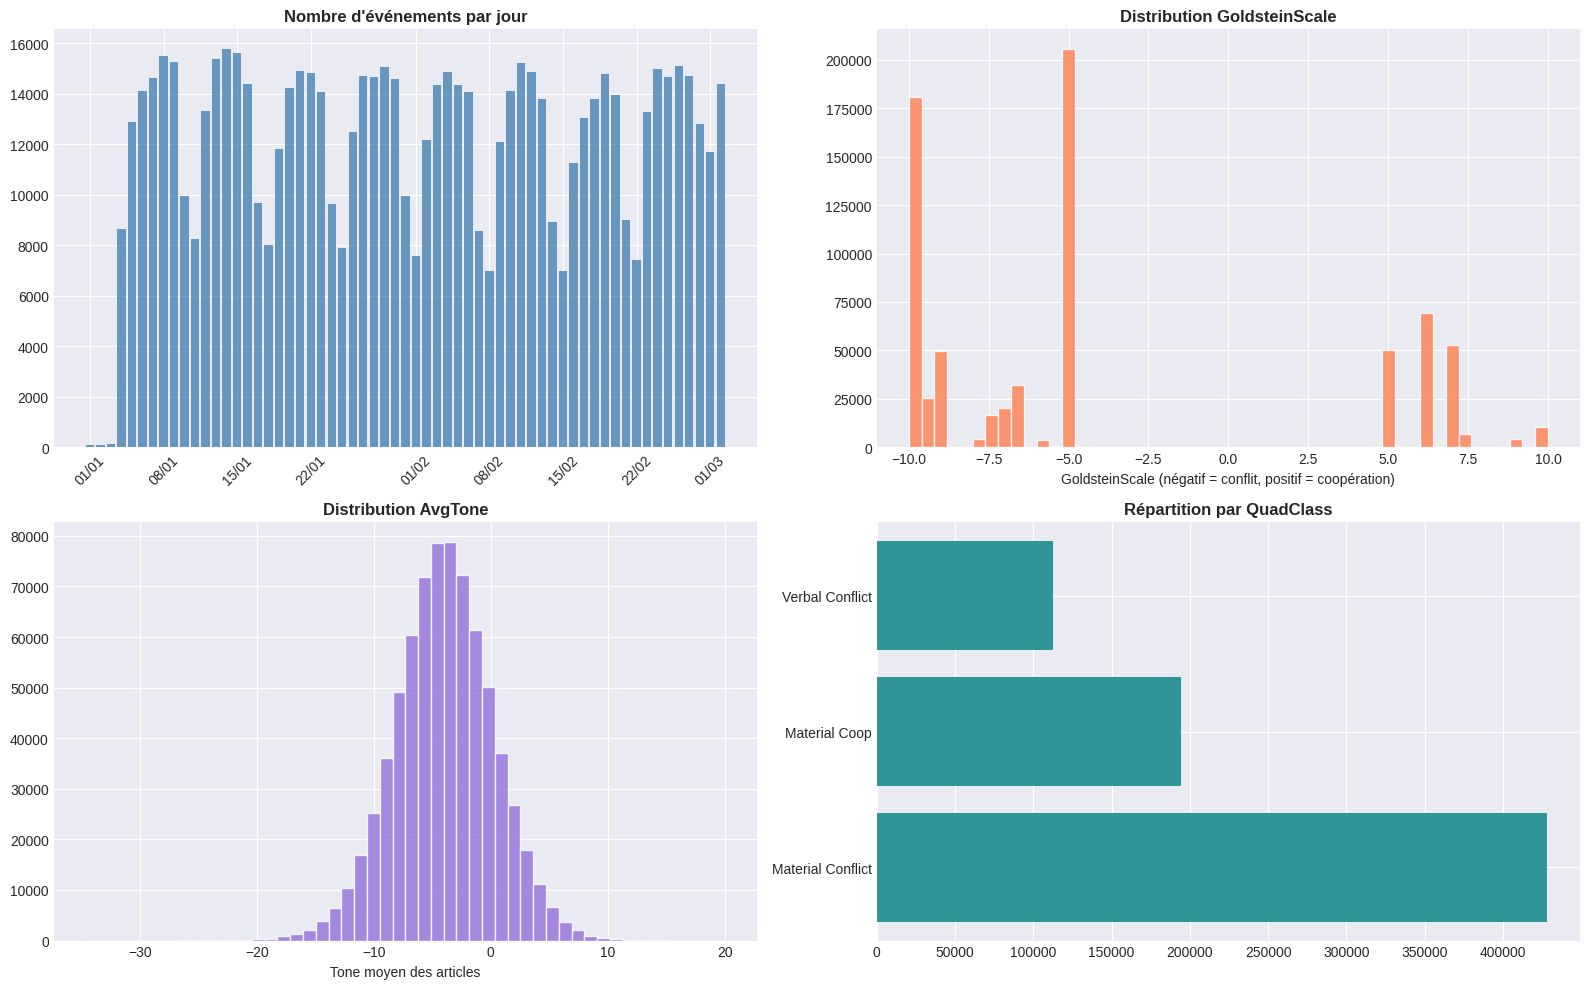

In [7]:
# ═══════════════════════════════════════════════
# Distribution des événements GDELT
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Nombre d'événements par jour
if "Day" in df_gdelt.columns:
    df_gdelt["Day_dt"] = pd.to_datetime(df_gdelt["Day"], format="%Y%m%d", errors="coerce")
    daily = df_gdelt.groupby("Day_dt").size()
    axes[0, 0].bar(daily.index, daily.values, color="steelblue", alpha=0.8)
    axes[0, 0].set_title("Nombre d'événements par jour", fontweight="bold")
    axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Distribution GoldsteinScale
if "GoldsteinScale" in df_gdelt.columns:
    axes[0, 1].hist(df_gdelt["GoldsteinScale"].dropna(), bins=50, color="coral", alpha=0.8, edgecolor="white")
    axes[0, 1].set_title("Distribution GoldsteinScale", fontweight="bold")
    axes[0, 1].set_xlabel("GoldsteinScale (négatif = conflit, positif = coopération)")

# 3. Distribution AvgTone
if "AvgTone" in df_gdelt.columns:
    axes[1, 0].hist(df_gdelt["AvgTone"].dropna(), bins=50, color="mediumpurple", alpha=0.8, edgecolor="white")
    axes[1, 0].set_title("Distribution AvgTone", fontweight="bold")
    axes[1, 0].set_xlabel("Tone moyen des articles")

# 4. Top 10 QuadClass
if "QuadClass" in df_gdelt.columns:
    top_quad = df_gdelt["QuadClass"].value_counts().head(10)
    quad_labels = {1: "Verbal Coop", 2: "Material Coop", 3: "Verbal Conflict", 4: "Material Conflict"}
    top_quad.index = [quad_labels.get(int(x), str(x)) for x in top_quad.index]
    axes[1, 1].barh(top_quad.index, top_quad.values, color="teal", alpha=0.8)
    axes[1, 1].set_title("Répartition par QuadClass", fontweight="bold")

plt.tight_layout()
plt.show()

In [8]:
# ═══════════════════════════════════════════════
# Aperçu dernières lignes GDELT
# ═══════════════════════════════════════════════
print(f"Dernières lignes :")
df_gdelt.tail(200)

Dernières lignes :


,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,NumMentions,NumSources,NumArticles,AvgTone,geo_I,geo_B,geo_S,geo_score_raw,dominant_country,Day_dt
734083,1291968888,2026-03-02,2026-03-02 19:45:00,CVL,COMMUNITY,None,CVL,GBR,UNITED KINGDOM,GBR,...,4,1,4,-3.007038,2.0,1.609438,1.030070,6.631337,GBR,2026-03-02
734084,1291968889,2026-03-02,2026-03-02 19:45:00,CVL,VOTER,None,CVL,GOV,PRESIDENT,None,...,6,1,6,2.080238,1.0,1.945910,1.000000,1.945910,None,2026-03-02
734085,1291968890,2026-03-02,2026-03-02 19:45:00,CVL,COMMUNITY,None,CVL,IRL,IRELAND,IRL,...,6,1,6,-3.007038,1.0,1.945910,1.030070,2.004424,None,2026-03-02
734086,1291968907,2026-03-02,2026-03-02 19:45:00,CVL,POPULATION,None,CVL,USA,COLORADO,USA,...,5,1,5,-9.264706,3.0,1.791759,1.842647,29.714223,USA,2026-03-02
734087,1291968937,2026-03-02,2026-03-02 19:45:00,EDU,COLLEGE,None,EDU,None,None,None,...,6,1,6,-2.795031,1.0,1.945910,1.027950,2.000299,None,2026-03-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
734278,1291969729,2026-03-02,2026-03-02 19:45:00,RUS,RUSSIA,RUS,None,UKR,UKRAINE,UKR,...,12,1,12,-5.938242,6.0,2.564949,2.559382,236.328707,RUS,2026-03-02
734279,1291969904,2026-03-02,2026-03-02 19:45:00,USA,UNITED STATES,USA,None,None,None,None,...,10,1,6,-10.526316,3.0,1.945910,2.605263,45.626472,USA,2026-03-02
734280,1291969937,2026-03-02,2026-03-02 19:45:00,USA,UNITED STATES,USA,None,COP,PRISON,None,...,4,1,4,-8.163265,3.0,1.609438,1.831633,26.531091,USA,2026-03-02
734281,1291970028,2026-03-02,2026-03-02 19:45:00,USA,PENNSYLVANIA,USA,None,IRN,IRAN,IRN,...,4,1,4,-3.443114,7.0,1.609438,2.534431,199.871468,IRN,2026-03-02


In [9]:
# ═══════════════════════════════════════════════
# Affichage des 20 premières lignes GDELT
# ═══════════════════════════════════════════════
df_gdelt.head(100)

,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,NumMentions,NumSources,NumArticles,AvgTone,geo_I,geo_B,geo_S,geo_score_raw,dominant_country,Day_dt
0,1282069477,2026-01-04,2026-01-03 23:00:00,None,None,None,None,AUS,AUSTRALIA,AUS,...,4,1,4,1.608187,1.0,1.609438,2.500000,4.023595,None,2026-01-04
1,1282069529,2026-01-04,2026-01-03 23:00:00,None,None,None,None,IRL,LIMERICK,IRL,...,10,1,10,-7.547170,1.0,2.397895,1.825472,4.377290,None,2026-01-04
2,1282069542,2026-01-04,2026-01-03 23:00:00,None,None,None,None,LEG,CONGRESS,None,...,20,2,20,-4.117647,1.0,3.044522,1.791176,5.453277,None,2026-01-04
3,1282069544,2026-01-04,2026-01-03 23:00:00,None,None,None,None,LEG,CHAMBER,None,...,10,1,10,-1.865369,1.0,2.397895,2.443654,5.859626,None,2026-01-04
4,1282069551,2026-01-04,2026-01-03 23:00:00,None,None,None,None,MIL,MILITARY,None,...,15,5,15,-4.152432,1.0,2.772589,2.541524,7.046602,None,2026-01-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1282069536,2026-01-04,2026-01-03 23:00:00,None,None,None,None,JUD,JUDICIARY,None,...,4,1,4,-7.620818,1.0,1.609438,2.576208,4.146247,None,2026-01-04
96,1282069543,2026-01-04,2026-01-03 23:00:00,None,None,None,None,LEG,CHAMBER,None,...,10,1,10,-1.865369,1.0,2.397895,2.398654,5.751720,None,2026-01-04
97,1282069579,2026-01-04,2026-01-03 23:00:00,None,None,None,None,USA,NEW YORK,USA,...,10,1,10,-3.781513,3.0,2.397895,1.037815,22.397148,USA,2026-01-04
98,1282069587,2026-01-04,2026-01-03 23:00:00,None,None,None,None,USA,UNITED STATES,USA,...,9,1,9,-3.802281,3.0,2.302585,1.788023,37.053672,USA,2026-01-04


In [10]:
print(df_gdelt.iloc[110])

GlobalEventID                     1282069950
Day                               2026-01-04
DATEADDED                2026-01-03 23:00:00
Actor1Code                               FRA
Actor1Name                            FRANCE
Actor1CountryCode                        FRA
Actor1Type1Code                         None
Actor2Code                               CHE
Actor2Name                             SWISS
Actor2CountryCode                        CHE
Actor2Type1Code                         None
EventCode                                190
EventRootCode                             19
QuadClass                                  4
GoldsteinScale                         -10.0
IsRootEvent                                1
ActionGeo_CountryCode                     FR
ActionGeo_Lat                        49.4333
ActionGeo_Long                       1.08333
NumMentions                                5
NumSources                                 1
NumArticles                                5
AvgTone   

In [11]:
# Filtrer les lignes avec OPC en Actor1Code ou Actor2Code
df_opc = df_gdelt[(df_gdelt['Actor1Code'] == 'GOVOPC') | (df_gdelt['Actor2Code'] == 'GOVOPC')]

print(f"Nombre de lignes avec OPC : {len(df_opc)}")
df_opc.head(50)

Nombre de lignes avec OPC : 0


,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,NumMentions,NumSources,NumArticles,AvgTone,geo_I,geo_B,geo_S,geo_score_raw,dominant_country,Day_dt


In [12]:
import numpy as np

# ═══════════════════════════════════════════════
# Ajout des colonnes "buzz" et "gravité pondérée"
# ═══════════════════════════════════════════════


# Création d'une copie du dataset filtré pour ajouter les nouvelles colonnes
df_gdelt_enriched = filter_all.copy()

# Calcul de "Le buzz" : log(1 + NumArticles)
df_gdelt_enriched['buzz'] = np.log(1 + df_gdelt_enriched['NumArticles'])

# Calcul de "La Gravité pondérée" : (10 - Goldstein) × (1 + (100 - AvgTone) / 50)
df_gdelt_enriched['gravite_ponderee'] = (
    (10 - df_gdelt_enriched['GoldsteinScale']) * 
    (1 + (100 - df_gdelt_enriched['AvgTone']) / 50)
)

print(f"✅ Nouvelles colonnes ajoutées : 'buzz' et 'gravite_ponderee'")
print(f"📊 Shape du dataset enrichi : {df_gdelt_enriched.shape[0]} lignes × {df_gdelt_enriched.shape[1]} colonnes\n")
print("=" * 150)
print("Aperçu des 100 premières lignes :\n")
df_gdelt_enriched.head(100)
df_gdelt_enriched.describe()


NameError: name 'filter_all' is not defined

In [ ]:
# ═══════════════════════════════════════════════
# Analyse de l'impact des filtres avec EventRootCode
# ═══════════════════════════════════════════════

relevant_event_codes = [6, 8,10,11,12, 13, 14, 15, 16, 17, 18, 19, 20]

df_base = df_gdelt.copy()
total = len(df_base)

# Calcul de chaque filtre individuellement
f_eventroot = df_base['EventRootCode'].isin(relevant_event_codes)
f_numart    = df_base['NumArticles'] >= 4
f_goldstein = df_base['GoldsteinScale'].abs() >= 5
f_quadclass = df_base['QuadClass'] >= 2

# Construction du tableau d'impact
filters_summary = [
    ("Aucun filtre (données initiales)",                       total),
    ("EventRootCode ∈ liste",                                  f_eventroot.sum()),
    ("NumArticles >= 4",                                       f_numart.sum()),
    ("|GoldsteinScale| >= 5",                                  f_goldstein.sum()),
    ("QuadClass >= 2",                                         f_quadclass.sum()),
    ("EventRootCode ∈ liste ET NumArticles >= 4",              (f_eventroot & f_numart).sum()),
    ("EventRootCode ∈ liste ET |GoldsteinScale| >= 5",         (f_eventroot & f_goldstein).sum()),
    ("EventRootCode ∈ liste ET QuadClass >= 2",                (f_eventroot & f_quadclass).sum()),
    ("NumArticles >= 4 ET |GoldsteinScale| >= 5",              (f_numart & f_goldstein).sum()),
    ("NumArticles >= 4 ET QuadClass >= 2",                     (f_numart & f_quadclass).sum()),
    ("|GoldsteinScale| >= 5 ET QuadClass >= 2",                (f_goldstein & f_quadclass).sum()),
    ("TOUS LES FILTRES COMBINÉS",                              (f_numart & f_goldstein & f_quadclass).sum()),
]

results_extended = pd.DataFrame(filters_summary, columns=["Filtre(s) appliqué(s)", "Nombre de lignes"])
results_extended["% restant"]  = (results_extended["Nombre de lignes"] / total * 100).round(2)
results_extended["Lignes retirées"] = total - results_extended["Nombre de lignes"]
results_extended["% retiré"]   = (results_extended["Lignes retirées"] / total * 100).round(2)

print(f"Total initial : {total:,} lignes\n")
print(f"Codes EventRootCode conservés : {relevant_event_codes}\n")
display(results_extended)

# Aperçu du dataset final avec tous les filtres combinés
df_final = df_base[f_numart & f_goldstein & f_quadclass].copy()
print(f"\n✅ Dataset final (tous filtres) : {len(df_final):,} lignes × {df_final.shape[1]} colonnes")
df_final.head(20)

In [ ]:
# Affichage des 20 premières lignes du GDELT
df_gdelt.head(20)

In [13]:
# Vérifier les codes pays réels dans les données GDELT
print("=== Actor1CountryCode ===")
print(df_gdelt["Actor1CountryCode"].value_counts().head(20))
print("\n=== Actor2CountryCode ===")
print(df_gdelt["Actor2CountryCode"].value_counts().head(20))
print("\n=== ActionGeo_CountryCode ===")
print(df_gdelt["ActionGeo_CountryCode"].value_counts().head(20))

=== Actor1CountryCode ===
Actor1CountryCode
USA    125735
GBR     18682
IRN     14431
ISR     13886
CAN      9890
RUS      9818
AUS      8920
IND      8545
CHN      8161
NGA      7048
UKR      6037
PAK      5734
VEN      5641
EUR      5300
FRA      4853
PSE      4375
AFR      4200
DNK      3607
IRL      3475
DEU      3376
Name: count, dtype: int64

=== Actor2CountryCode ===
Actor2CountryCode
USA    79837
IRN    13226
GBR    12707
ISR    10223
RUS     9001
CHN     6776
VEN     6659
CAN     6560
AUS     6232
UKR     5893
NGA     5678
PSE     4872
IND     4798
PAK     4128
EUR     4072
DNK     3685
FRA     3195
AFR     2822
SYR     2588
MEX     2587
Name: count, dtype: int64

=== ActionGeo_CountryCode ===
ActionGeo_CountryCode
US    240839
IN     37235
UK     36985
IR     28803
IS     26705
NI     20192
AS     18916
CA     18870
RS     15805
CH     14630
VE     13221
PK     12668
UP      9649
FR      7443
BG      6558
SF      6343
EI      6305
MX      6276
SY      5661
GM      5186
Name: 